# Google — the evidence walk

**What this notebook is.** One pass over the committed evidence for the Google
seat, from what was collected to what may be said out loud. It reads only the
aggregate tables under `members/ankit-google/task-*-tables/`, which are in the
repository, so it runs on a fresh clone with no data files and no API keys.

**What it is not.** It is not where the analysis happens. Every number below
is produced by a runner in [`src/`](../src) and committed as a table; the
notebook loads those tables and shows the shape of the argument. If a number
here disagrees with a table, the table is right and this notebook is stale —
the last cell fails loudly when that happens.

**Reading order.** The sections follow the argument, not the task numbers:
what was collected, what a posting count actually counts, and then only the
results that survive that answer.

```bash
python -m pytest tests/ -q          # the checks behind every table below
python src/build_presentation.py    # the deck these numbers appear on
```

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.width", 100)
pd.set_option("display.max_columns", 40)

MEMBER = Path.cwd().parent / "members" / "ankit-google"


def table(task: int, name: str) -> pd.DataFrame:
    """Load one committed aggregate table by task number and file name."""
    return pd.read_csv(MEMBER / f"task-{task:02d}-tables" / f"{name}.csv")


print(MEMBER.relative_to(Path.cwd().parent), "—",
      len(list(MEMBER.glob("task-*-tables/*.csv"))), "committed tables")

members/ankit-google — 127 committed tables


## 1. What was collected, and what the screen removed

Six companies clear the feasibility screen. The screen is not a formality: it
is why no claim in this project compares Google with OpenAI or Anthropic, both
of which are in the collected data and neither of which has the support to
carry a comparison.

In [2]:
screen = table(6, "company-feasibility-screen")
screen[["company", "postings", "months_present", "publishers", "verdict", "reason"]]

,company,postings,months_present,publishers,verdict,reason
0,openai,14,7,6,excluded_low_support,under 250 postings; present in 7/12 months
1,anthropic,9,4,5,excluded_low_support,under 250 postings; present in 4/12 months
2,meta,1029,12,102,included,NaN
3,google,848,12,95,included,NaN
4,microsoft,654,12,88,included,NaN
5,snowflake,463,12,37,included,NaN
6,databricks,340,12,39,included,NaN
7,nvidia,271,12,43,included,NaN


In [3]:
included = screen[screen.verdict == "included"]
excluded = screen[screen.verdict != "included"]
print(f"{len(included)} companies included, {len(excluded)} excluded")
print(f"{included.postings.sum():,} postings in the comparison pool")

comparability = table(6, "company-comparability")
google = comparability[comparability.company == "google"].iloc[0]
print(f"\nGoogle: {google.postings:,} postings, {google.publishers} publishers, "
      f"{google.months_observed} months of 2023")
print(f"top publisher: {google.top_publisher} at {google.top_publisher_share:.1%} of postings")

6 companies included, 2 excluded
3,605 postings in the comparison pool

Google: 846 postings, 95 publishers, 12 months of 2023
top publisher: via LinkedIn at 25.3% of postings


The screen counts **848** postings for Google and the comparability table
counts **846**. That gap is deliberate and recorded as
[C4](../docs/corrections.md#c4--googles-posting-count-is-846-not-848): the
screen selects on the employer name pattern, and Task 06's matching audit found
two of those rows are not Google — a reseller listing and a namesake. Every
number downstream of the audit uses 846. The screen table keeps its original
figure, because a register is not an eraser.

## 2. The identification result everything else leans on

A posting count is a count of the **boards that syndicate a posting**, not a
count of hires. Google appears through 95 publishers, and which publishers are
present changes from month to month — so a monthly count mixes a hiring signal
with a syndication signal, and nothing in the data separates them.

`panel-sensitivity.csv` is that problem measured. Four defensible treatments of
the publisher panel are indexed to January. They do not agree on the direction
of the year.

In [4]:
panel = table(5, "panel-sensitivity")
indices = ["raw_index", "balanced_index", "chained_index", "bilateral_index"]
december = panel[panel.period == "2023-12"][["period"] + indices]
print("December, indexed to January = 100:")
print(december.to_string(index=False))

directions = {name: ("up" if december[name].iloc[0] > 100 else "down") for name in indices}
print("\ndirection by treatment:", directions)
print("agree on a sign:", len(set(directions.values())) == 1)

December, indexed to January = 100:
 period  raw_index  balanced_index  chained_index  bilateral_index
2023-12      91.11          115.38         185.38           191.18

direction by treatment: {'raw_index': 'down', 'balanced_index': 'up', 'chained_index': 'up', 'bilateral_index': 'up'}
agree on a sign: False


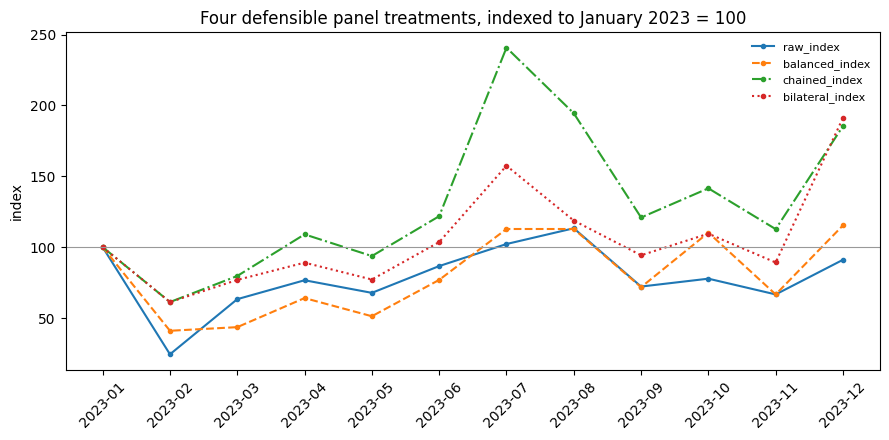

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for name, style in zip(indices, ["-", "--", "-.", ":"]):
    ax.plot(panel.period, panel[name], style, marker="o", ms=3, label=name)
ax.axhline(100, color="0.6", lw=0.8)
ax.set_title("Four defensible panel treatments, indexed to January 2023 = 100")
ax.set_ylabel("index")
ax.tick_params(axis="x", rotation=45)
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

The spread between the lines is the identification limit, and it is wide enough
that "Google's hiring rose in 2023" and "Google's hiring fell in 2023" are both
consistent with the data. Task 05 recorded the volume direction as **not
identified**, and every later task inherits that: the deck carries the refusal
rather than a direction.

## 3. What survives: share of a common publisher pool

Levels do not compare across companies, because each company is syndicated by a
different set of boards. Share of a **fixed pool of publishers that carry every
company** does compare — with a caveat, recorded as
[C8](../docs/corrections.md#c8--a-unanimity-count-is-not-a-robustness-statistic-when-the-number-of-tests-moves-with-the-threshold),
that the agreement count moves with the per-publisher cell floor.

In [6]:
verdict = table(6, "relative-share-verdict")
print(verdict.to_string(index=False))
print("\nverdicts:", verdict.verdict.value_counts().to_dict())

   company  pooled_log_share_change  publishers_tested  publishers_agreeing   verdict     direction
databricks                    0.293                  6                    4     mixed gaining share
    google                   -0.182                  6                    4     mixed  losing share
      meta                    0.050                  6                    5     mixed gaining share
 microsoft                    0.237                  6                    4     mixed gaining share
    nvidia                    0.347                  6                    6 confirmed gaining share
 snowflake                   -1.190                  6                    5     mixed  losing share

verdicts: {'mixed': 5, 'confirmed': 1}


## 4. Forecasting: the question has an answer, and it is no

Task 07 ran a model contest against a persistence benchmark at every horizon
the data supports. Nothing beat it.

In [7]:
contest = table(7, "model-contest")
print("models tested:", sorted(contest.model.unique()))
print("horizons tested:", sorted(contest.horizon.unique()))
print("model-horizon pairs beating persistence:", int(contest.beats_benchmark.sum()),
      f"of {len(contest)}")

horizons = table(7, "horizon-limits")
print("\nper-horizon RMSE against the naive benchmark:")
print(horizons[["horizon", "model", "n_origins", "rmse", "achieved_level",
                "interval_sufficient"]].head(6).to_string(index=False))

models tested: ['ar1', 'drift', 'holt_damped', 'loglinear', 'mean', 'ses']
horizons tested: [1, 2, 3]
model-horizon pairs beating persistence: 0 of 18

per-horizon RMSE against the naive benchmark:
 horizon model  n_origins     rmse  achieved_level  interval_sufficient
       1 naive         12 0.308898        0.846154                 True
       2 naive         10 0.295449        0.818182                 True
       3 naive          8 0.367326             NaN                False


## 5. Similarity: one pair of fifteen is actually separated

Fifteen company pairs, five metrics, two nulls, and four robustness levers
(metric family, own-product vendor terms, role mix, resampling). A pair counts
as identified only when its rank survives all four.

In [8]:
pairs = table(8, "pair-verdicts")
print(pairs.verdict.value_counts().to_string())
print()
print(pairs[pairs.verdict == "robust"][["company_a", "company_b", "rank",
                                        "observed", "reason"]].to_string(index=False))

verdict
unresolved          13
robust               1
vendor_dependent     1

company_a company_b  rank  observed                                                                       reason
   google      meta     1    0.9174 rank 1 in 100% of resamples, stable across metric, own products and role mix


## 6. From evidence to sentences

Task 09 generated the claims mechanically from the verdict tables above, then
put each one through four gates: evidence, language, identification and
consistency. The yield is the deliverable as much as the published claims are.

436 claims generated
120 publishable (27.5%)
316 refused


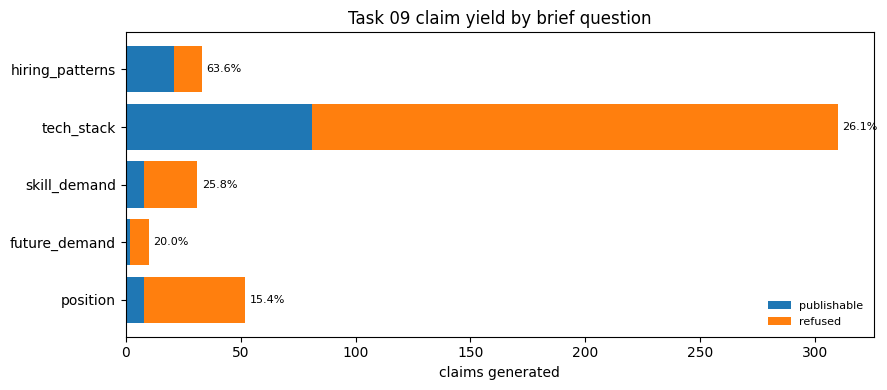

In [9]:
yield_table = table(9, "insight-yield")
overall = yield_table[yield_table.question == "all"].iloc[0]
print(f"{int(overall.generated)} claims generated")
print(f"{int(overall.published) + int(overall.published_qualified)} publishable "
      f"({overall.yield_pct}%)")
print(f"{int(overall.refused)} refused")

by_question = yield_table[yield_table.question != "all"].copy()
by_question["publishable"] = by_question.published + by_question.published_qualified
by_question = by_question.sort_values("yield_pct")

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(by_question.question, by_question.publishable, label="publishable")
ax.barh(by_question.question, by_question.refused,
        left=by_question.publishable, label="refused")
for y, (pct, total) in enumerate(zip(by_question.yield_pct, by_question.generated)):
    ax.text(total + 2, y, f"{pct}%", va="center", fontsize=8)
ax.set_title("Task 09 claim yield by brief question")
ax.set_xlabel("claims generated")
ax.legend(frameon=False, fontsize=8, loc="lower right")
fig.tight_layout()
plt.show()

## 7. What reaches the deck

The Task 10 deck spends the ledger rather than paraphrasing it. Every bullet is
one of four kinds, and only one of them lets the presenter write a sentence
containing a number: a `fact` bullet, whose numerals come from a resolver that
reads this repository.

In [10]:
bullets = pd.read_csv(MEMBER / "task-10-tables" / "deck-bullets.csv")
print(bullets.kind.value_counts().to_string())
print()
ledger_bound = bullets[bullets.kind.isin(["claim", "refusal"])]
print(f"{len(ledger_bound)} bullets are quoted verbatim from the claim ledger, "
      f"{ledger_bound.claim_id.nunique()} distinct claims")
print("refusals on the deck:", sorted(bullets[bullets.kind == "refusal"].claim_id))

kind
plain      38
fact       10
claim       9
refusal     4

13 bullets are quoted verbatim from the claim ledger, 13 distinct claims
refusals on the deck: ['salary-google-meta-science-research', 'tempting-country', 'tempting-forecast', 'tempting-level']


In [11]:
facts = pd.read_csv(MEMBER / "task-10-tables" / "deck-facts.csv")
print(facts[["key", "value", "description", "source"]].to_string(index=False))

                   key  value                                   description                                                         source
        postings_focus    846      postings collected for the focus company              task-06-tables/company-comparability.csv#postings
      publishers_focus     95      publishers syndicating the focus company            task-06-tables/company-comparability.csv#publishers
       months_observed     12        months the focus company is present in       task-06-tables/company-comparability.csv#months_observed
    companies_compared      6  companies that passed the feasibility screen          task-06-tables/company-feasibility-screen.csv#verdict
companies_screened_out      2                 companies the screen excluded          task-06-tables/company-feasibility-screen.csv#verdict
         postings_pool  3,605        postings across every included company         task-06-tables/company-feasibility-screen.csv#postings
       skills_observed     

## 8. Self-check

Prose goes stale silently; that is the failure this repository is built against.
Every number quoted in the markdown above is asserted here against the table it
came from, so a rebuild that moves a number fails this notebook instead of
leaving a confident sentence standing.

In [12]:
checks = {
    "six companies included": len(included) == 6,
    "google is 846 postings": int(google.postings) == 846,
    "google is 95 publishers": int(google.publishers) == 95,
    "panel treatments disagree on the sign": len(set(directions.values())) > 1,
    "no model beats persistence": int(contest.beats_benchmark.sum()) == 0,
    "one robust pair": int((pairs.verdict == "robust").sum()) == 1,
    "436 claims generated": int(overall.generated) == 436,
    "no personal-data column in any table read here": not any(
        "candidate" in column.lower()
        for frame in (screen, comparability, panel, verdict, contest, pairs,
                      yield_table, bullets, facts)
        for column in frame.columns
    ),
}
for label, ok in checks.items():
    print(f"{'PASS' if ok else 'FAIL'} — {label}")
assert all(checks.values()), "this notebook is stale against the committed tables"

PASS — six companies included
PASS — google is 846 postings
PASS — google is 95 publishers
PASS — panel treatments disagree on the sign
PASS — no model beats persistence
PASS — one robust pair
PASS — 436 claims generated
PASS — no personal-data column in any table read here
